#### Initial Descriptive Stats

1. Loading Data

Since the processed job ad data are stored in CSV files, first import the necessary libraries and read the data.

In [2]:
## Loading Data
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from IPython.display import display
import seaborn as sns

In [47]:
# Set the path to the processed CSV files
DATA_FOLDER = "processed_data_preprocessed"  # Update if needed

# Get list of CSV files in the folder
csv_files = [file for file in os.listdir(DATA_FOLDER) if file.endswith(".csv")]

# Load each file into a DataFrame and collect them
df_list = []
for file in csv_files:
    file_path = os.path.join(DATA_FOLDER, file)
    try:
        df_part = pd.read_csv(file_path, encoding="utf-8")
        df_list.append(df_part)
    except Exception as e:
        print(f"Failed to load {file}: {e}")

# Merge all DataFrames
df_all = pd.concat(df_list, ignore_index=True)

# Display and save preview
print(df_all.head())
df_all.head().to_csv("head_of_data.csv", index=False, encoding="utf-8")

# Save the merged DataFrame to a CSV file

df_all.to_csv("df_desc.csv", index=False, encoding="utf-8")


   summary_AutomatchType  summary_Abroad  summary_Weight  \
0                      0           False               1   
1                      0           False               1   
2                      0           False               1   
3                      0           False               1   
4                      0           False               1   

                                       summary_Title  \
0  Træd speederen i bund og bliv teknisk rådgiver...   
1  LindbergHR søger regnskabskonsulent med et par...   
2  Fængselslærer til institution Sdr. Omme - Sdr....   
3  Social- og sundhedsassistent til dagvagt 35 ti...   
4  BØRNEHUSET VANDET SØGER EN PÆDAGOG, FASTANSÆTT...   

                                 summary_JobHeadline  \
0  Træd speederen i bund og bliv teknisk rådgiver...   
1  LindbergHR søger regnskabskonsulent med et par...   
2  Fængselslærer til institution Sdr. Omme - Sdr....   
3  Social- og sundhedsassistent til dagvagt 35 ti...   
4  BØRNEHUSET VANDET S

In [42]:
# Load the saved preview if needed to check output - uncomment next line to use

#df_head = pd.read_csv("head_of_data.csv")

In [6]:
# Uncomment if you have previously saved the DataFrame from the above chunks and simply want to run the chunks below (e.g., for visualisation)
#df_all = pd.read_csv("df_desc.csv")

/var/folders/wb/6mdx7sq923sft6mn64xx6b600000gn/T/ipykernel_40331/185508620.py:1: DtypeWarning: Columns (137,139) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all = pd.read_csv("df_desc.csv")


2. Validation

Checking for duplicates, missing values, empty columns

In [48]:
# Check for Duplicates
df_all.duplicated().sum()

0

In [38]:
# If needed, uncomment and run to remove duplicates
#df_all = df_all.drop_duplicates()

In [7]:
# Drop empty columns and show which ones were removed
before_cols = df_all.shape[1]
empty_cols = df_all.columns[df_all.isna().all()].tolist()
df_all = df_all.drop(columns=empty_cols)
after_cols = df_all.shape[1]

print(f"Removed {before_cols - after_cols} completely empty columns.")
if empty_cols:
    print("Dropped columns:")
    for col in empty_cols:
        print(f" - {col}")
else:
    print("No completely empty columns were found.")


Removed 45 completely empty columns.
Dropped columns:
 - summary_PostalCodeName
 - details_JobPositionPosting_HiringOrg_FaxNumber
 - details_JobPositionPosting_RecruitingCompany
 - details_JobPositionPosting_JobPositionInformation_WeeklyWorkHours_Description
 - details_JobPositionPosting_JobPositionInformation_CompensationDescription
 - details_JobLogTemplateModel_CvCustomerIdentifier
 - details_JobLogTemplateModel_JobSeekingStatus
 - details_JobLogTemplateModel_ApplicationSource
 - details_JobLogTemplateModel_HoursPerWeek
 - details_JobLogTemplateModel_JobAdDocument_Title
 - details_JobLogTemplateModel_JobAdDocument_Identifier
 - details_JobLogTemplateModel_JobAdFile
 - details_JobLogTemplateModel_Company_Country
 - details_JobLogTemplateModel_Company_EmploymentAreaID
 - details_JobLogTemplateModel_Company_Latitude
 - details_JobLogTemplateModel_Company_Longitude
 - details_JobLogTemplateModel_Company_DailyTravelTimeInMinutes
 - details_JobLogTemplateModel_Company_DistanceToCompanyInM

In [8]:
# Create null summary
null_summary = df_all.isnull().sum().reset_index()
null_summary.columns = ["Column", "Missing_Values"]
null_summary = null_summary.sort_values(by="Missing_Values", ascending=False)

# Create stats_outputs folder if it doesn't exist
output_stats_dir = "stats_outputs"
os.makedirs(output_stats_dir, exist_ok=True)

# Define full path to the output file
output_path = os.path.join(output_stats_dir, "null_summary.csv")

# Save to CSV
null_summary.to_csv(output_path, index=False, encoding="utf-8")

print(f"Missing value summary saved to '{output_path}'")

print(null_summary.head(10))

Missing value summary saved to 'stats_outputs/null_summary.csv'
                                                Column  Missing_Values
132  details_JobPositionPosting_ApplicationDetails_...           24659
200  details_JobPositionPosting_ContactAuthorityPho...           24656
63                         details_WorkPlace_FaxNumber           24652
216  details_JobPositionPosting_RecruitingCompany_W...           24439
209  details_JobPositionPosting_RecruitingCompany_A...           24403
217  details_JobPositionPosting_RecruitingCompany_W...           24393
206  details_JobPositionPosting_RecruitingCompany_A...           24393
215  details_JobPositionPosting_RecruitingCompany_F...           24239
218  details_JobPositionPosting_RecruitingCompany_O...           24141
208  details_JobPositionPosting_RecruitingCompany_A...           23876


3. Quick Info

This will give an overview of columns, data types, and missing values. Mostly here as a sanity check.

In [9]:
# Get DataFrame info
df_info = df_all.info()

# Display DataFrame info
display(df_info)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24668 entries, 0 to 24667
Columns: 219 entries, summary_AutomatchType to details_JobPositionPosting_RecruitingCompany_OrganizationNumber
dtypes: bool(45), float64(38), int64(24), object(112)
memory usage: 33.8+ MB


None

4. Summary Statistics

To get a summary of the columns in the dataset.

In [10]:
#df_all.describe()

# Get summary statistics for all columns
df_categorical_summary = df_all.describe(include="object")

# Display the summary statistics
display(df_categorical_summary)


,summary_Title,summary_JobHeadline,summary_Presentation,summary_HiringOrgName,summary_WorkPlaceAddress,summary_WorkPlaceCity,summary_PostingCreated,summary_LastDateApplication,summary_FormattedLastDateApplication,summary_AssignmentStartDate,...,details_MapUrl,text_preprocessed,details_JobPositionPosting_ContactAuthorityPhoneNumber_Description,details_JobPositionPosting_RecruitingCompany_Name,details_JobPositionPosting_RecruitingCompany_Address_AddressLine,details_JobPositionPosting_RecruitingCompany_Address_Country_Name,details_JobPositionPosting_RecruitingCompany_Address_Region_Name,details_JobPositionPosting_RecruitingCompany_Address_City,details_JobPositionPosting_RecruitingCompany_PhoneNumber_Description,details_JobPositionPosting_RecruitingCompany_WebAddress
count,24668,24668,24632,24668,21819,23757,24668,24668,24668,24668,...,24668,24668,14617,847,802,275,265,802,802,229
unique,23589,23589,23199,6922,11263,568,5802,870,128,1,...,11605,24242,1,90,55,1,4,55,1,40
top,Rengøringsassistent,Rengøringsassistent,Kunne du tænke dig at få muligheden for at ska...,Københavns Kommune,,København NV,2022-05-04T00:00:00,2022-05-31T00:00:00,16. februar 2025,0001-01-01T00:00:00,...,https://www.google.dk/maps/place/Borups+Allé+1...,jobbet du vil skulle støtte og afløse off-trad...,Primary,Jobcenter Lolland,Lillievej 4,Danmark,Syddanmark,Nakskov,Primary,http://silkeborgkommune.dk/
freq,25,25,66,806,654,898,1270,873,948,24668,...,462,19,14617,46,66,275,84,66,802,26


5. Distribution of Job Titles

List the amount of each job title, and how many unique job titles there are

In [11]:
# Get job title counts
job_title_counts = df_all["summary_Occupation"].value_counts()

# Display the full list
print(job_title_counts)

# Count unique job titles
num_unique_titles = df_all["summary_Occupation"].nunique()
print(f"Total distinct job titles: {num_unique_titles}")

# Save to stats_outputs
output_stats_dir = "stats_outputs"
os.makedirs(output_stats_dir, exist_ok=True)

# Convert to DataFrame for saving
job_title_counts_df = job_title_counts.reset_index()
job_title_counts_df.columns = ["Job Title", "Count"]

# Save to CSV
output_path = os.path.join(output_stats_dir, "job_title_counts.csv")
job_title_counts_df.to_csv(output_path, index=False, encoding="utf-8")

# Print confirmation message
print(f"Job title counts saved to '{output_path}'")

summary_Occupation
Pædagog                                           1610
Sygeplejerske                                     1258
Social- og sundhedsassistent                      1232
Social- og sundhedshjælper                         766
Folkeskolelærer                                    593
                                                  ... 
Lektor                                               1
Lektor, professionshøjskole og erhvervsakademi       1
Forsikringselev                                      1
Lektor, humaniora                                    1
Redaktør                                             1
Name: count, Length: 799, dtype: int64
Total distinct job titles: 799
Job title counts saved to 'stats_outputs/job_title_counts.csv'


6. Plotting Descriptive Statistics

Creating visualizations to explore the data.

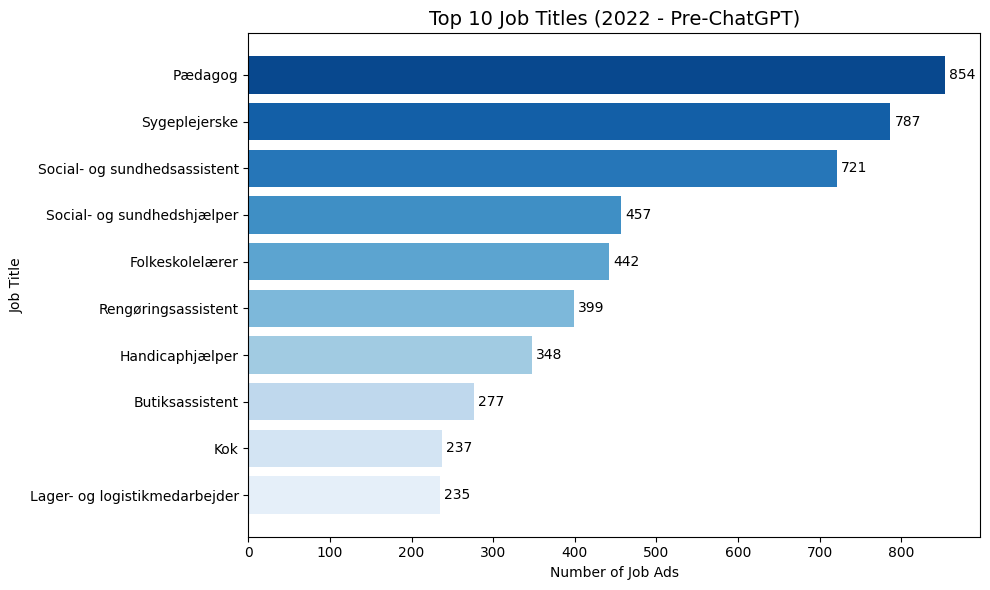

Plot saved to 'plot_outputs/top_10_job_titles_2022.png'


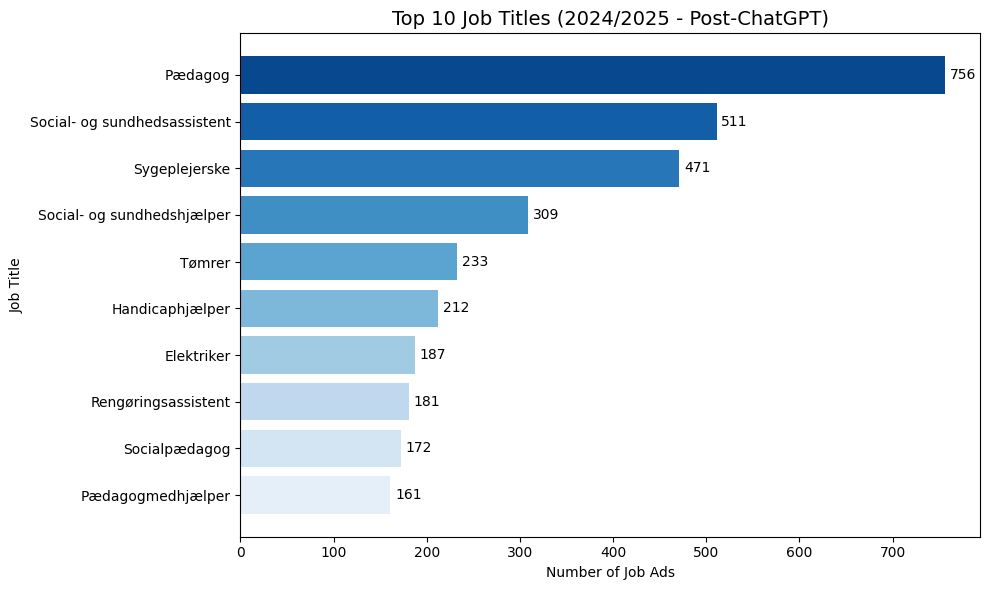

Plot saved to 'plot_outputs/top_10_job_titles_2024_2025.png'


In [15]:
# Create output directory
output_plot_dir = "plot_outputs"
os.makedirs(output_plot_dir, exist_ok=True)

# Ensure datetime format and assign period group
df_all["summary_PostingCreated"] = pd.to_datetime(df_all["summary_PostingCreated"], errors='coerce')
df_all["Posting_Year"] = df_all["summary_PostingCreated"].dt.year
df_all["Period_Group"] = df_all["Posting_Year"].apply(
    lambda x: "2022 - Pre-ChatGPT" if x == 2022 else ("2024/2025 - Post-ChatGPT" if x in [2024, 2025] else None)
)

# Function to create and save a bar plot
def plot_top_job_titles(period_label, output_filename, color_palette="Blues"):
    subset = df_all[df_all["Period_Group"] == period_label]
    job_counts = subset["summary_Occupation"].value_counts().head(10)[::-1]
    colors = sns.color_palette(color_palette, n_colors=10)

    plt.figure(figsize=(10, 6))
    bars = plt.barh(job_counts.index, job_counts.values, color=colors)

    for bar in bars:
        width = bar.get_width()
        plt.text(width + 5, bar.get_y() + bar.get_height() / 2,
                 f'{int(width)}', va='center', fontsize=10)

    plt.title(f"Top 10 Job Titles ({period_label})", fontsize=14)
    plt.xlabel("Number of Job Ads")
    plt.ylabel("Job Title")
    plt.tight_layout()

    plot_path = os.path.join(output_plot_dir, output_filename)
    plt.savefig(plot_path, dpi=300)
    plt.show()
    print(f"Plot saved to '{plot_path}'")

# Generate one plot per period
plot_top_job_titles("2022 - Pre-ChatGPT", "top_10_job_titles_2022.png")
plot_top_job_titles("2024/2025 - Post-ChatGPT", "top_10_job_titles_2024_2025.png")


## Grouping and Plotting Job Advertisements by Year Posted


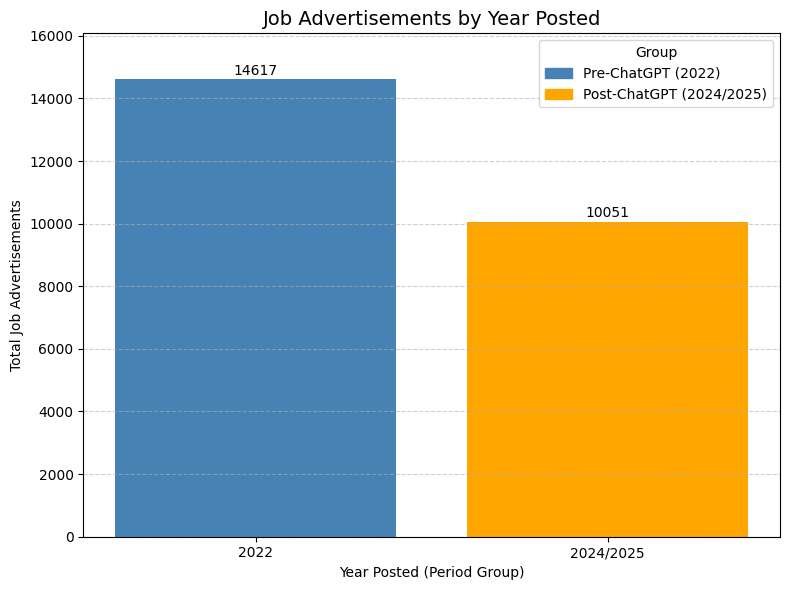

Plot saved to: plot_outputs/yearly_job_postings_grouped.png


In [13]:

# Convert to datetime and extract year
posting_dates = pd.to_datetime(df_all["summary_PostingCreated"], errors="coerce")
years = posting_dates.dt.year

# Group years into pre/post ChatGPT categories
grouped_years = years.apply(lambda y: "2022" if y == 2022 else ("2024/2025" if y in [2024, 2025] else None))
df_grouped = grouped_years.value_counts().sort_index()

# Define bar colors
bar_colors = ["steelblue" if year == "2022" else "orange" for year in df_grouped.index]

# Output directory
output_plot_dir = "plot_outputs"
os.makedirs(output_plot_dir, exist_ok=True)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(df_grouped.index, df_grouped.values, color=bar_colors)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 50, f"{int(height)}", ha='center', va='bottom', fontsize=10)

# Labels and formatting
ax.set_title("Job Advertisements by Year Posted", fontsize=14)
ax.set_xlabel("Year Posted (Period Group)")
ax.set_ylabel("Total Job Advertisements")
ax.set_ylim(0, max(df_grouped.values) * 1.1)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()

# Add legend
legend_handles = [
    Patch(color="steelblue", label="Pre-ChatGPT (2022)"),
    Patch(color="orange", label="Post-ChatGPT (2024/2025)")
]
ax.legend(handles=legend_handles, title="Group")

# Save plot
output_path = os.path.join(output_plot_dir, "yearly_job_postings_grouped.png")
plt.savefig(output_path, dpi=300)
plt.show()

# Print confirmation message
print(f"Plot saved to: {output_path}")

### WordClouds

Saved: plot_outputs/word_cloud_titles_2022.png
Saved: plot_outputs/word_cloud_titles_2024_2025.png


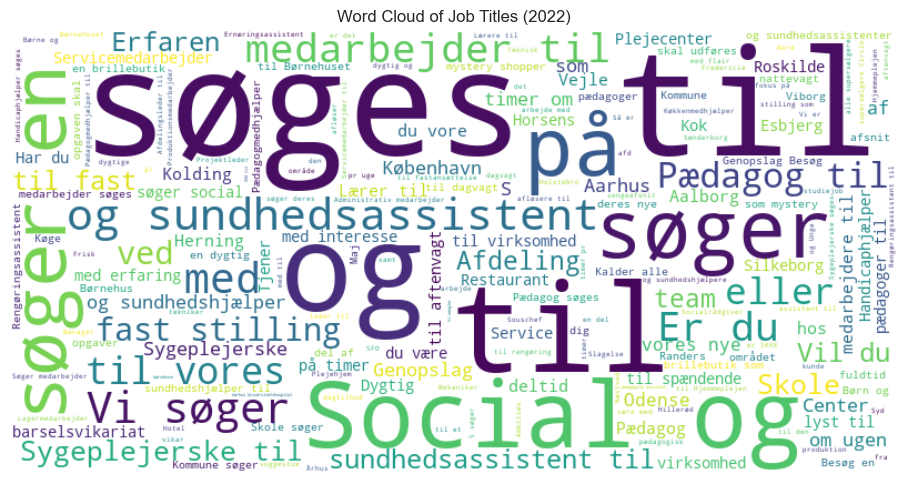

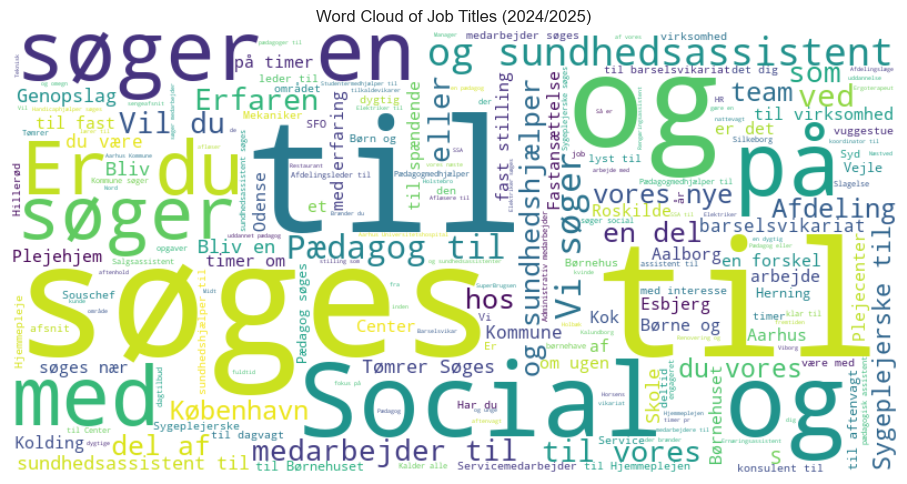

In [64]:
import os
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd

# Ensure output directory exists
output_plot_dir = "plot_outputs"
os.makedirs(output_plot_dir, exist_ok=True)

# Convert posting date to datetime and extract year
df_all["summary_PostingCreated"] = pd.to_datetime(df_all["summary_PostingCreated"], errors="coerce")
df_all["Posting_Year"] = df_all["summary_PostingCreated"].dt.year

# Group by period
df_all["Period_Group"] = df_all["Posting_Year"].apply(
    lambda x: "2022" if x == 2022 else ("2024/2025" if x in [2024, 2025] else None)
)

# Function to create and save word cloud
def generate_wordcloud(texts, title, filename):
    text = " ".join(texts.dropna())
    wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.tight_layout()
    
    path = os.path.join(output_plot_dir, filename)
    plt.savefig(path, dpi=300)
    #plt.close()
    print(f"Saved: {path}")

# Generate for each period
generate_wordcloud(
    df_all[df_all["Period_Group"] == "2022"]["summary_Title"],
    "Word Cloud of Job Titles (2022)",
    "word_cloud_titles_2022.png"
)

generate_wordcloud(
    df_all[df_all["Period_Group"] == "2024/2025"]["summary_Title"],
    "Word Cloud of Job Titles (2024/2025)",
    "word_cloud_titles_2024_2025.png"
)

#last: 9.7s

### Filter Job Advertisements Starting with Links


In [125]:
# Check if descriptions start with http or www
df_links = df_all[
    df_all["details_JobPositionPosting_JobPositionInformation_Purpose"].str.startswith(("http", "www"), na=False)
]

# Output directory
output_stats_dir = "stats_outputs"
os.makedirs(output_stats_dir, exist_ok=True)

# Define output path
links_output_path = os.path.join(output_stats_dir, "job_ads_starting_with_links.csv")

# Save to CSV
df_links.to_csv(links_output_path, index=False, encoding="utf-8")

print(f"Filtered dataset saved to: {links_output_path}")

print(f" Found {len(df_links)} job advertisements that start with a link")

## Check the output, if there are any that starts with link. If they *only* contain link then remove them, if not, keep them 
# filter out the job advertisements that start with a link, if you decide they are not relevant
df_all = df_all[~df_all["details_JobPositionPosting_JobPositionInformation_Purpose"].str.startswith(("http", "www"), na=False)]

# print the number of job advertisements that were removed
print(f"Removed {len(df_links)} job advertisements that started with a link.")


Filtered dataset saved to: stats_outputs/job_ads_starting_with_links.csv
 Found 9 job advertisements that start with a link


### Save the filtered DataFrame

In [65]:
# Save a csv of the dataframe as it looks now after running the above chunks:

df_all.to_csv("df_desc_filt.csv", index=False, encoding="utf-8")

In [4]:
df_check = pd.read_csv("df_desc_filt.csv", encoding="utf-8")

# Describe dataframe colum details_JobPositionPosting_JobPositionInformation_Purpose
print(df_check.describe(include="object"))

/var/folders/wb/6mdx7sq923sft6mn64xx6b600000gn/T/ipykernel_40331/3906388500.py:1: DtypeWarning: Columns (132,134) have mixed types. Specify dtype option on import or set low_memory=False.
  df_check = pd.read_csv("df_desc_filt.csv", encoding="utf-8")


              summary_Title  summary_JobHeadline  \
count                 24668                24668   
unique                23589                23589   
top     Rengøringsassistent  Rengøringsassistent   
freq                     25                   25   

                                     summary_Presentation  \
count                                               24632   
unique                                              23199   
top     Kunne du tænke dig at få muligheden for at ska...   
freq                                                   66   

       summary_HiringOrgName summary_WorkPlaceAddress summary_WorkPlaceCity  \
count                  24668                    21819                 23757   
unique                  6922                    11263                   568   
top       Københavns Kommune                                   København NV   
freq                     806                      654                   898   

       summary_PostingCreated summary